# Artistic Era Classifier (Aedion Model)
This model is intended to classify the artistic era of a painting, in conjunction with the main Ashryver V2 model, as a fallback in case the Ashryver model is unable to identify the artist for the painting. The model recognizes ten key eras: **Renaissance, Baroque, Neoclassicism, Realism, Impressionism, Romanticism, Cubism, Surrealism, Abstract Expressionism, Pop Art.**

In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from fastai.vision.all import * # fastai image classification
!pip install -Uqq duckduckgo_search==5.3.1b1
!pip install timm

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# Define the dataset folder explicitly so the name is stable across cells
painting_era_data = Path('painting_era_data')
print('painting_era_data =', painting_era_data)
painting_era_data.mkdir(exist_ok=True, parents=True)

painting_data = Path('painting_data')

painting_era_data = painting_era_data


In [27]:
!pip install -U albumentations

In [19]:
import time
from duckduckgo_search import DDGS
from fastcore.all import *

# Define basic search images function for testing purposes only
def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
        time.sleep(2)
        return [r['image'] for r in results]

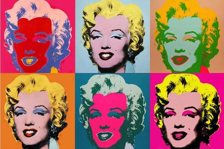

In [6]:
from fastdownload import download_url
from fastai.vision.all import *

# Test to see what kind of results we get
urls = search_images('pop art painting', max_images=1)
urls[0] 
 
dest = 'pop-art-painting.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(224,224) # show a preview of the image

In [20]:
# Renaissance, Baroque, Neoclassicism, Realism, Impressionism, Romanticism, Cubism, Surrealism, Abstract Expressionism, Pop Art
# Define function to download painting images

def download_painting_images(era_names: list,
                           output_dir: Path = Path('painting_data'),
                           images_per_era: int = 400,
                           URL: str = None):
    """Reusable function to download images of paintings efficiently.

    URL: optional query string or template for searches. If provided and containing
    '{era_name}' it will be formatted per-artist, otherwise the literal string
    will be used for every artist. If omitted, a sensible default excluding
    common stock sites is used per-artist.
    """
    output_dir.mkdir(exist_ok=True, parents=True)

    for era_name in era_names:
        era_dir = output_dir / era_name
        era_dir.mkdir(exist_ok=True, parents=True)

        # Determine query to use for this era
        if URL is None:
            query = era_name + " painting -site:gettyimages.com -site:alamy.com -site:123rf.com -site:vecteezy.com -watermark -alamy -shutterstock -istockphoto -depositphotos -dreamstime -adobe stock -britannica"
        else:
            try:
                query = URL.format(era_name=era_name)
            except Exception:
                # If formatting fails, fall back to using the URL string as-is
                query = URL

        urls = search_images(query, max_images=images_per_era)

        download_images(era_dir, urls=urls)
        print(f"Downloaded {len(urls)} images for {era_name}")

# Pull down photos of the first 5 eras
eras_batch_1 = ['renaissance', 'baroque', 'neoclassicist', 'realist', 'impressionist']
download_painting_images(eras_batch_1)

Downloaded 243 images for renaissance
Downloaded 274 images for baroque
Downloaded 302 images for neoclassicist
Downloaded 186 images for realist
Downloaded 338 images for impressionist


In [21]:
eras_batch_2 = ['romanticist', 'cubist', 'surrealist', 'abstract expressionist', 'pop art']
download_painting_images(eras_batch_2)

Downloaded 312 images for romanticist
Downloaded 265 images for cubist
Downloaded 307 images for surrealist
Downloaded 323 images for abstract expressionist
Downloaded 267 images for pop art


In [22]:
# Check to see if any of the images failed to download properly
failed = verify_images(get_image_files(painting_data))
# verify_images returns a list (or L) of file paths that failed verification
for f in failed:
    try:
        Path(f).unlink()
    except Exception as e:
        print(f'Could not remove {f}: {e}')
print(f'Removed {len(failed)} failed images.')

Removed 6 failed images.


# Train the model

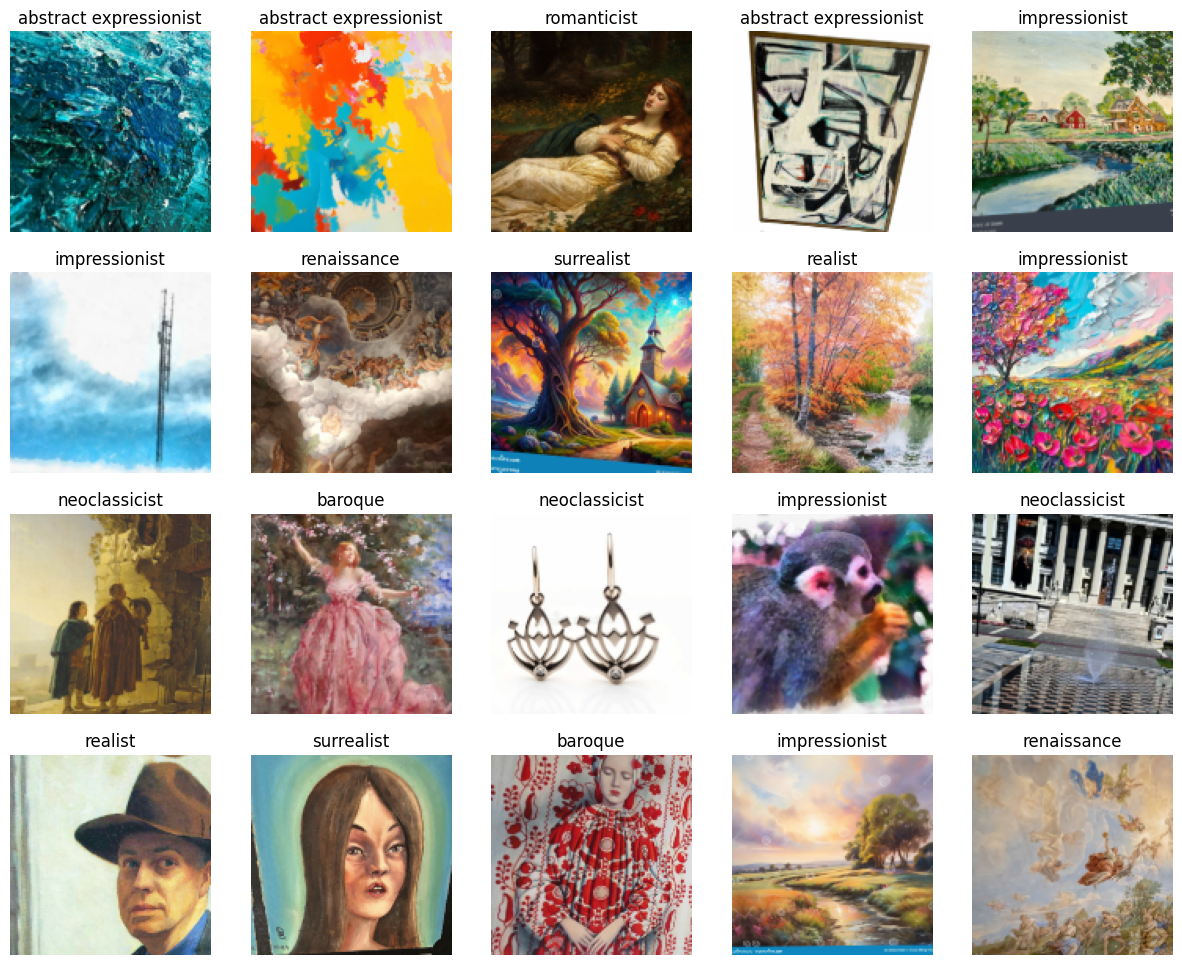

In [35]:
import albumentations as A
from fastai.vision.all import *
import numpy as np
import cv2
# Dataset statistics: train items: 2081, valid items: 520

class AlbumentationsTransform(ItemTransform):
    split_idx = 0
    def __init__(self, aug): 
        self.aug = aug
    def encodes(self, x: PILImage):
        img = np.array(x)
        return PILImage.create(self.aug(image=img)["image"])

# 2. Define your custom augmentation function
def get_custom_aug():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
    ])

import albumentations as A
# Set up data augmentation to randomly add watermarks, since many of the data items are noisy it seems
class RandomTextOverlay(A.ImageOnlyTransform):
    def __init__(self, always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        
    def apply(self, image, **params):
        # Create a copy so we don't mutate original tensors
        img = image.copy()
        h, w = img.shape[:2]
        
        # Draw random synthetic text
        text_options = ["SAMPLE", "AI Generated", "STOCKPHOTO", "TEST", "STUPID"]
        text = np.random.choice(text_options)
        
        # Randomize placement and font size
        font_scale = np.random.uniform(0.5, 1.5)
        thickness = np.random.randint(1, 3)
        x = np.random.randint(0, w // 3)
        y = np.random.randint(h // 4, h - (h // 4))
        
        # Apply synthetic text overlay to the numpy array
        cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 
                    font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
        return img
    
# Compose the augmentation pipeline
def get_custom_aug():
    return A.Compose([
        RandomTextOverlay(p=0.6), # 60% chance of applying the text overlay
        A.CoarseDropout(p=0.3)    # Odds random blocky noise/watermarks, may choose to reprove
    ])

# Create the Datablock
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    # Use a larger item resize, then apply aug_transforms on the batch
    item_tfms=[Resize(224), AlbumentationsTransform(get_custom_aug())],
    batch_tfms=[*aug_transforms(size=128), Normalize.from_stats(*imagenet_stats)]
).dataloaders(painting_data, bs=32)

dls.show_batch(max_n=20) # show a sample of 20 images that the model will be trained upon

In [36]:
# Train the resnet34 model
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(4) # train for 4 epochs

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 149MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,2.741680,1.737038,0.484513,01:07


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,1.975801,1.642341,0.455752,01:09
1,1.738014,1.502330,0.453540,01:09
2,1.389081,1.476359,0.420354,01:08
3,1.076616,1.437162,0.424779,01:07


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [40]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

img = PILImage.create('painting-test-1.png')

# Get the prediction from the trained model
pred_label, pred_idx, probs = learn.predict(img)
all_probs = probs.tolist()

# Map art movements to their proper descriptive adjectives with a dictionary
movement_to_adjective = {
    'renaissance': 'Renaissance',
    'baroque': 'Baroque',
    'neoclassicism': 'Neoclassical',
    'realism': 'Realistic',
    'impressionism': 'Impressionist',
    'cubism': 'Cubist',
    'surrealism': 'Surrealist',
    'abstract expressionism': 'Abstract Expressionist',
    'pop art': 'Pop Art'
}

# Get the adjective, falling back to the label itself if it isn't in the dictionary
pred_adj = movement_to_adjective.get(pred_label, pred_label)

# Determine 'a' vs 'an' based on the first letter of the adjective
article = "an" if pred_adj[0].lower() in 'aeiou' else "a"

print(f"This is {article} {pred_adj} painting.\n============================\nAll Probabilities")
for class_name, probability in zip(learn.dls.vocab, all_probs):
    prob_val = probability * 100  # format to a percentage
    if class_name == pred_label:
        print(f"\033[1;32m{class_name}: {prob_val:.2f}%\033[0m")  # output the predicted label as bold and green
    else:
        print(f"{class_name}: {prob_val:.2f}%")
show_image(img)

# Model incorrectly classified a pop-art Andy Warhol painting as impressionist

<div><progress max="15" value="3"></progress> 20.00% [3/15 00:04&lt;00:19... 1.0766]</div>

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


KeyboardInterrupt: 

# Get some statistics on the model's performance

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(448, method='squish')] # 224x224 image size for capturing more fine details
).dataloaders(painting_data, bs=32)

learn.dls = dls

print("train items:", len(learn.dls.train.dataset))
print("valid items:", len(learn.dls.valid.dataset))
print("vocab:", learn.dls.vocab)

def evaluate_model(learn, test_dl=None):
    """Get detailed metrics on how the classification model is performing"""
    if test_dl is None:
        test_dl = learn.dls.valid
    elif isinstance(test_dl, DataLoaders):
        test_dl = test_dl.valid

    if len(test_dl.dataset) == 0:
        raise ValueError("test_dl is empty; cannot evaluate model performance")

    preds, targs = learn.get_preds(dl=test_dl)
    if preds is None:
        raise RuntimeError("learn.get_preds() returned None. Ensure the learner and DataLoader are valid.")

    pred_classes = preds.argmax(dim=1)

    from sklearn.metrics import classification_report, confusion_matrix

    print("=== Classification Report ===")
    print(classification_report(targs, pred_classes, target_names=learn.dls.vocab))

    return confusion_matrix(targs, pred_classes)

evaluate_model(learn)

train items: 2239
valid items: 559
vocab: ['abstract expressionist', 'baroque', 'cubist', 'impressionism', 'neoclassicism', 'pop art', 'post-impressionist', 'realism', 'renaissance', 'surrealist']


=== Classification Report ===
                        precision    recall  f1-score   support

abstract expressionist       0.53      0.49      0.51        35
               baroque       0.44      0.83      0.57        63
                cubist       0.62      0.54      0.58        57
         impressionism       0.47      0.56      0.51        48
         neoclassicism       0.40      0.58      0.47        55
               pop art       0.73      0.69      0.71        55
    post-impressionist       0.65      0.42      0.52        40
               realism       0.42      0.28      0.34        61
           renaissance       0.75      0.49      0.60        85
            surrealist       0.55      0.43      0.49        60

              accuracy                           0.53       559
             macro avg       0.56      0.53      0.53       559
          weighted avg       0.56      0.53      0.53       559



array([[17,  1,  1,  7,  2,  1,  0,  2,  0,  4],
       [ 0, 52,  1,  1,  4,  0,  1,  2,  1,  1],
       [ 4,  1, 31,  1,  2,  8,  1,  4,  0,  5],
       [ 1,  3,  0, 27,  6,  0,  3,  3,  3,  2],
       [ 1, 12,  1,  0, 32,  1,  1,  3,  3,  1],
       [ 4,  0,  6,  0,  2, 38,  0,  2,  1,  2],
       [ 0,  3,  2, 12,  4,  0, 17,  0,  2,  0],
       [ 3,  8,  1,  6, 17,  3,  1, 17,  1,  4],
       [ 0, 28,  2,  1,  9,  0,  1,  0, 42,  2],
       [ 2, 10,  5,  2,  3,  1,  1,  7,  3, 26]])

In [46]:
# Export our crummy first model just for reference (it won't even be tracked by Git anyway, and we can just delete it later once we train better models)
learn.export('era_classifier_v2_resnet50_448x448_2798items_2026.pkl')